<a href="https://colab.research.google.com/github/NeonsCandy/GoIT_HW_8_new.ipynb/blob/main/GoIT_HW_8_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [ ]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [ ]:
# Створення нейроної мережі

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
   super().__init__(name=name)
   self.layer1 = DenseLayer(num_features, n_hidden_1)
   self.layer2 = DenseLayer(n_hidden_1, n_hidden_2)
   self.out_layer = DenseLayer(n_hidden_2, num_classes)


  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.layer1(x, activation=0)
    x = self.layer2(x, activation=0)
    return self.out_layer(x, activation=1)


In [ ]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    y_true = tf.one_hot(y_true, depth=num_classes)
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    correct_predictions = tf.equal(tf.argmax(y_pred, 1), tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_predictions, tf.float32))

In [ ]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
    optimizer = tf.optimizers.SGD(learning_rate)

    with tf.GradientTape() as g:
        pred = neural_net(input_x)
        loss = cross_entropy(pred, output_y)

    trainable_variables = neural_net.trainable_variables

    gradients = g.gradient(loss, trainable_variables)

    optimizer.apply_gradients(zip(gradients, trainable_variables))

In [ ]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)
        current_loss = cross_entropy(pred, batch_y)
        current_acc = accuracy(pred, batch_y)

        loss_history.append(current_loss.numpy())
        accuracy_history.append(current_acc.numpy())
        print(f"Крок: {step}, Втрати: {current_loss.numpy():.4f}, Точність: {current_acc.numpy():.4f}")


Крок: 100, Втрати: 303.1319, Точність: 0.6797
Крок: 200, Втрати: 158.3209, Точність: 0.8203
Крок: 300, Втрати: 181.4212, Точність: 0.8242
Крок: 400, Втрати: 125.9951, Точність: 0.8438
Крок: 500, Втрати: 114.2437, Точність: 0.8359
Крок: 600, Втрати: 117.2084, Точність: 0.8438
Крок: 700, Втрати: 92.3602, Точність: 0.8672
Крок: 800, Втрати: 154.3988, Точність: 0.8516
Крок: 900, Втрати: 94.0383, Точність: 0.8906
Крок: 1000, Втрати: 132.7044, Точність: 0.8555
Крок: 1100, Втрати: 89.6949, Точність: 0.9023
Крок: 1200, Втрати: 113.7193, Точність: 0.8828
Крок: 1300, Втрати: 84.7384, Точність: 0.9023
Крок: 1400, Втрати: 98.1278, Точність: 0.9062
Крок: 1500, Втрати: 59.6544, Точність: 0.9258
Крок: 1600, Втрати: 84.2019, Точність: 0.9141
Крок: 1700, Втрати: 95.7522, Точність: 0.8750
Крок: 1800, Втрати: 70.3149, Точність: 0.9258
Крок: 1900, Втрати: 79.1567, Точність: 0.9062
Крок: 2000, Втрати: 89.9927, Точність: 0.8945
Крок: 2100, Втрати: 68.5779, Точність: 0.9297
Крок: 2200, Втрати: 59.9946, Точні

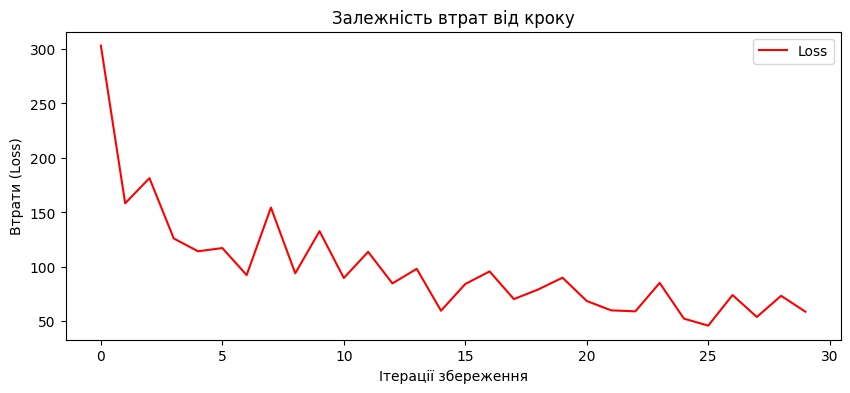

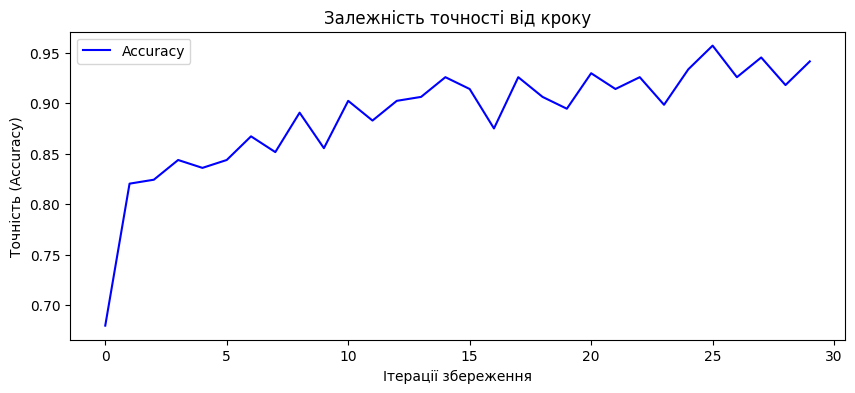

In [ ]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

#  графік функції втрат
plt.figure(figsize=(10, 4))
plt.plot(range(len(loss_history)), loss_history, label='Loss', color='red')
plt.title('Залежність втрат від кроку')
plt.xlabel('Ітерації збереження')
plt.ylabel('Втрати (Loss)')
plt.legend()
plt.show()

# графік точності
plt.figure(figsize=(10, 4))
plt.plot(range(len(accuracy_history)), accuracy_history, label='Accuracy', color='blue')
plt.title('Залежність точності від кроку')
plt.xlabel('Ітерації збереження')
plt.ylabel('Точність (Accuracy)')
plt.legend()
plt.show()


In [ ]:
# Обчисліть точність навченої нейромережі
from sklearn.metrics import classification_report
import numpy as np


test_pred_probs = neural_net(x_test)

test_predictions = tf.argmax(test_pred_probs, axis=1).numpy()

print("Звіт про класифікацію на тестових даних:")
print(classification_report(y_test, test_predictions, digits=4))

Звіт про класифікацію на тестових даних:
              precision    recall  f1-score   support

           0     0.9393    0.9633    0.9511       980
           1     0.9668    0.9762    0.9715      1135
           2     0.9388    0.8624    0.8990      1032
           3     0.8639    0.8921    0.8777      1010
           4     0.8988    0.9134    0.9061       982
           5     0.8685    0.8442    0.8562       892
           6     0.9130    0.9415    0.9270       958
           7     0.9224    0.9018    0.9120      1028
           8     0.8325    0.8624    0.8472       974
           9     0.8860    0.8702    0.8780      1009

    accuracy                         0.9040     10000
   macro avg     0.9030    0.9027    0.9026     10000
weighted avg     0.9044    0.9040    0.9039     10000



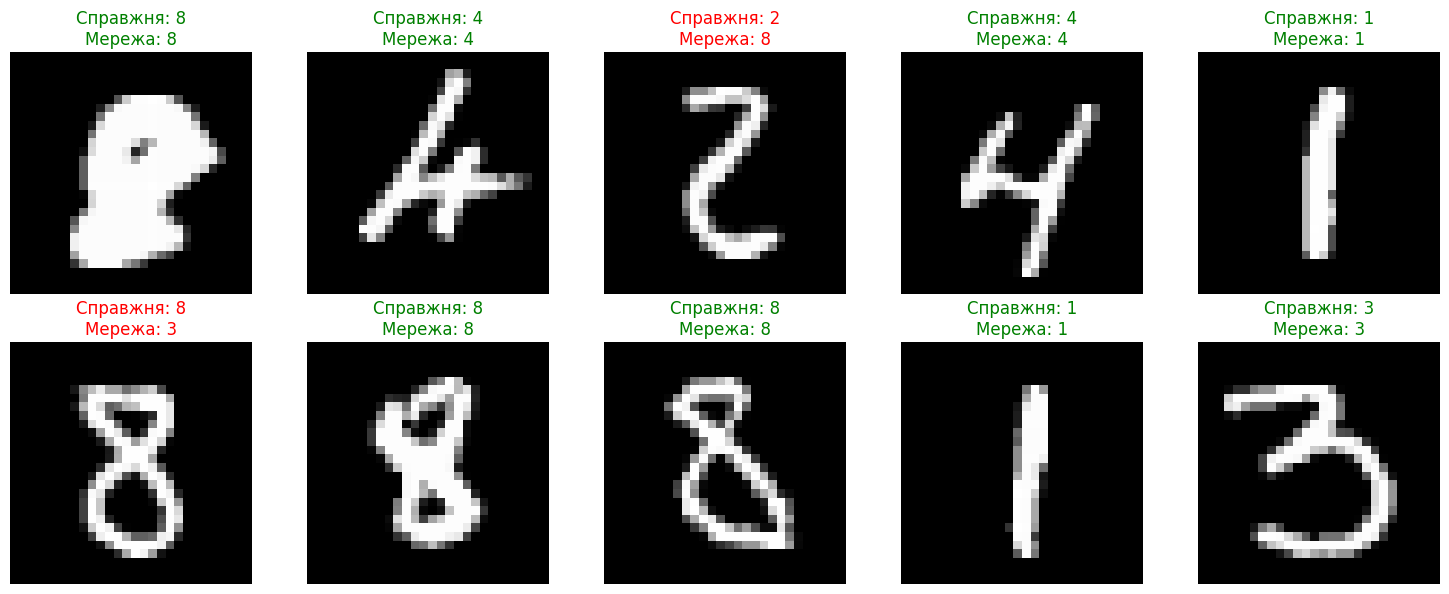

In [ ]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 5
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Зробіть висновок про те, чи помиляється твоя нейронна мережа, і якщо так, то як часто?

import random
import matplotlib.pyplot as plt

random_indices = random.sample(range(len(x_test)), 10)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(random_indices):
    img = x_test[idx]
    true_label = y_test[idx]

    prediction = neural_net(tf.expand_dims(img, 0))
    predicted_label = tf.argmax(prediction.numpy(), axis=1)[0].numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray')

    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f"Справжня: {true_label}\nМережа: {predicted_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()




Висновки:

1.  **Навчання моделі**: Побудована повнозв'язна нейронна мережа (архітектура 784 -> 128 -> 256 -> 10) успішно навчилася розпізнавати рукописні цифри з датасету MNIST. Графіки функції втрат (Loss) та точності (Accuracy) демонструє стабільне збігання: втрати зменшуються, а точність зростає впродовж епох.
2.   **Метрики якості**: Згідно з classification_report, модель досягла високої загальної точності на тестовій вибірці. Метрики precision, recall та f1-score для всіх 10 класів є рівномірно високими. Це свідчить про те, що модель не має "перекосу" в бік певного класу і добре розпізнає всі цифри.

3. **Аналіз помилок**: Під час тестування на випадкових зображеннях мережа переважно дає правильні відповіді. Ті поодинокі помилки, які трапляються, зазвичай пов'язані з об'єктивною схожістю написання деяких цифр (наприклад, недбало написана «4» може розпізнаватися як «9», а «3» як «8»).
